LangGraph
1. 基本控制
2. 串行控制
3.

定义State
****
- TypeDict: 属于Python标准库typing模块的一部分，仅提供静态类型检查，运行时不执行验证
- Pydantic： 第三方库，需要单独安装， 提供运行时数据验证和序列化功能

In [7]:
from operator import gt
from pyexpat.errors import messages

from langchain_core.messages import AnyMessage, AIMessage
from typing_extensions import TypedDict

# 定义节点间通讯的消息格式
class State(TypedDict):
    messages: list[AnyMessage]
    extra_f: int


定义节点

In [8]:
from langchain_core.messages import AnyMessage

def node(state: State):
    messages = state['messages']
    new_message = AIMessage("你好， 我是节点1")

    return {
        "messages": messages + [new_message],
        "extra_f": 1
    }

创建图
****
1. 包含一个节点
2. 使用State通信

In [4]:
from langgraph.graph import StateGraph
graph = StateGraph(State)
graph.add_node(node)
graph.set_entry_point("node")
graph_builder = graph.compile()


查看节点与图结构

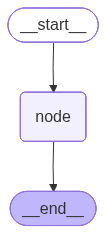

In [9]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

调用

In [11]:
from langchain_core.messages import HumanMessage
result = graph_builder.invoke({
    "messages": [HumanMessage("你好， 我是Tom")]
})
result

{'messages': [HumanMessage(content='你好， 我是Tom', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好， 我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_f': 1}

使用pretty_print来格式化显示

In [13]:
from langchain_core.messages import HumanMessage
result = graph_builder.invoke({
    "messages": [HumanMessage("你好， 我是Tom")]
})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

你好， 我是Tom
================================== Ai Message ==================================

你好， 我是节点1


串行控制

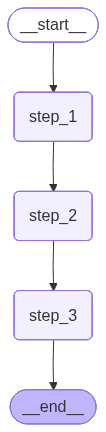

In [36]:
from typing_extensions import TypedDict
from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    value_1: str
    value_2: str
    value_3: str

def step_1(state: State):
    return {"value_1": "a"}

def step_2(state: State):
    current_value_1 = state['value_1']
    return {"value_2": f"{current_value_1} + b"}

def step_3(state: State):
    current_value_2 = state['value_2']
    return {"value_3": f"{current_value_2} + c" }

# 定义图
graph_builder = StateGraph(State)

# 添加节点
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

# 添加边[开始节点，结束节点]
graph_builder.add_edge(START, "step_1") # Start -> step_1
graph_builder.add_edge("step_1", "step_2") # step_1 -> step_2
graph_builder.add_edge("step_2", "step_3") # step_2 -> step_3
graph_builder.add_edge("step_3", END) # step_3 -> step_4

# 编译
graph = graph_builder.compile()

# 图转换为mermaid图
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
graph.invoke({"value_1": "m"})

{'value_1': 'a', 'value_2': 'a + b', 'value_3': 'a + b + c'}

分支控制

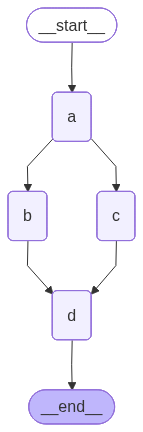

In [49]:
import operator
from typing import Any, Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Annotated 允许位类型提供额外的元数据， 而不影响类型检查器对类型本身的理解
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate": ["A"]}
def b(state: State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate": ["B"]}
def c(state: State):
    print(f"添加'C'到{state['aggregate']}")
    return {"aggregate": ["C"]}
def d(state: State):
    print(f"添加'D'到{state['aggregate']}")
    return {"aggregate": ["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [76]:
result = graph.invoke({"aggregate": []})

print(result)

print("-" * 50)

graph.invoke(
    {"aggregate": []},
    {"configurable": {"thread_id": "foo"}}
)

print("-" * 50)
for event in graph.stream({"aggregate": []}, stream_mode="updates"):

    print(event)

添加'A'到[]
添加'B'到['A']
添加'C'到['A']
添加'D'到['A', 'B', 'C']
{'aggregate': ['A', 'B', 'C', 'D']}
--------------------------------------------------
添加'A'到[]
添加'B'到['A']
添加'C'到['A']
添加'D'到['A', 'B', 'C']
--------------------------------------------------
添加'A'到[]
{'a': {'aggregate': ['A']}}
添加'B'到['A']
{'b': {'aggregate': ['B']}}
添加'C'到['A']
{'c': {'aggregate': ['C']}}
添加'D'到['A', 'B', 'C']
{'d': {'aggregate': ['D']}}


条件分支和循环

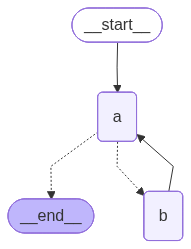

In [79]:
import operator
from typing import Any, Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Annotated 允许位类型提供额外的元数据， 而不影响类型检查器对类型本身的理解
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate": ["A"]}
def b(state: State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate": ["B"]}

builder = StateGraph(State)

# 定义节点
builder.add_node(a)
builder.add_node(b)

# 定义条件边
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START, "a")
# 条件边
builder.add_conditional_edges("a", route)
builder.add_edge("b", "a")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [104]:
result = graph.invoke({"aggregate": []})

添加'A'到[]
添加'B'到['A']
添加'A'到['A', 'B']
添加'B'到['A', 'B', 'A']
添加'A'到['A', 'B', 'A', 'B']
添加'B'到['A', 'B', 'A', 'B', 'A']
添加'A'到['A', 'B', 'A', 'B', 'A', 'B']


使用递归限制recursion_limit来防止异常情况下的大量无用调用

In [106]:
from langgraph.errors import GraphRecursionError
try:
    graph.invoke({"aggregate": []}, {"recursion_limit": 4})
except GraphRecursionError:
    print("Recursion Error")

添加'A'到[]
添加'B'到['A']
添加'A'到['A', 'B']
添加'B'到['A', 'B', 'A']
Recursion Error


循环

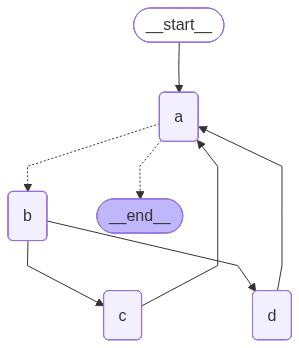

In [107]:
import operator
from typing import Any, Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Annotated 允许位类型提供额外的元数据， 而不影响类型检查器对类型本身的理解
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate": ["A"]}
def b(state: State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate": ["B"]}

builder = StateGraph(State)

# 定义节点
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

# 定义条件边
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START, "a")
# 条件边
builder.add_conditional_edges("a", route)
builder.add_edge("b", "c")
builder.add_edge("b", "d")
builder.add_edge(["c", "d"], "a")
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [108]:
result = graph.invoke({"aggregate": []})


添加'A'到[]
添加'B'到['A']
添加'C'到['A', 'B']
添加'D'到['A', 'B']
添加'A'到['A', 'B', 'C', 'D']
添加'B'到['A', 'B', 'C', 'D', 'A']
添加'C'到['A', 'B', 'C', 'D', 'A', 'B']
添加'D'到['A', 'B', 'C', 'D', 'A', 'B']
添加'A'到['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']



1. State: 一种共享数据结构，用于表示应用程序的当前快照。它可以是任何数据类型，但通常使用共享状态模式来定义。
2. Nodes：对智能体逻辑进行编码的函数。它们接收到当钱状态作为输入，执行一些计算或副作用，并返回更新后的状态。
3. Edges： 根据当前状态确定下一个要执行的Node的函数。它们可以是条件分支或固定转换。

In [18]:
from langgraph.graph import StateGraph, MessagesState, START, END

def this_is_a_method(params1: int, params2: int):
    print("this is a print")

# 1. 定义函数节点
def mock_llm(state: MessagesState):
    """模拟调用大模型"""
    return {"messages": [{"role": "ai", "content": "hello world"}]}

# 2. 定义图
builder = StateGraph(MessagesState)

# 3. 添加节点和边
builder.add_node("mock_llm", mock_llm)
builder.add_edge(START, "mock_llm")
builder.add_edge("mock_llm", END)

# 4. 编译图
graph = builder.compile()

response = graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

print (response)





{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='0f3f07ac-3f10-43a3-b553-eb16d7ca7d63'), AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='5301dd96-36e5-45c6-b474-584a63ecb49c', tool_calls=[], invalid_tool_calls=[])]}


In [12]:
from typing import TypedDict

# 状态的定义
class OverallState(TypedDict):
    user_input: str

# 节点的定义
def node_1(state: OverallState) -> OverallState:
    user_input = state['user_input']
    print(user_input)
    # return state['user_input']

# 注册图
builder = StateGraph(OverallState)

# 注册节点
builder.add_node("node_1", node_1)

# 注册边
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# 编译图
graph = builder.compile()

# 调用图
graph.invoke({"user_input": "hello"})



hello


{'user_input': 'hello'}